In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import pandas as pd

In [2]:
def time_axis(fs, duration):
    return np.arange(0, duration, 1/fs)
def gen_signal(f, t, A = 1, p = 0):
    return A*np.sin(2*np.pi*f*t + p)
def spectrum_taper(x, fs, NFFT = None):
    n = len(x)
    N = NFFT or n
    w = np.hanning(n) # use taper to help reduce leakage
    X = np.fft.fft((x - np.mean(x))*w, N)
    X = X[:N//2]
    mag = np.abs(X) * 2/N
    mag[0] = mag[0]/2
    mag[-1] = mag[-1]/2
    freq= np.arange(len(mag)) * fs/N
    return freq, mag

In [7]:
RGB_FILE = "../Lecture/Week11/rgb_average_25fps.csv"
REF_FILE = "../Lecture/Week11/pulse_fs100Hz_.txt"

FS_RGB = 25
FS_REF = 100

def load_rgb(path=RGB_FILE):
    df = pd.read_csv(path)
    timestamp = df["H"]*3600 + df["M"]*60 + df["S"]
    return df["R"].values, df["G"].values, df["B"].values, timestamp
def load_reference(path=REF_FILE):
    df = pd.read_csv(path, sep=r"\s+", header=None)
    ppg= df[3].values.astype(float)
    timestamp = df[0]*3600 + df[1]*60 + df[2]
    return ppg, timestamp

In [9]:
R, G, B, TIMESTAMP_RGB = load_rgb()
PPG, TIMESTAMP_PPG = load_reference()
DURATION_RGB = len(R)/FS_RGB ; print(DURATION_RGB)
DURATION_REF = len(PPG)/FS_REF ; print(DURATION_REF)

120.0
120.84


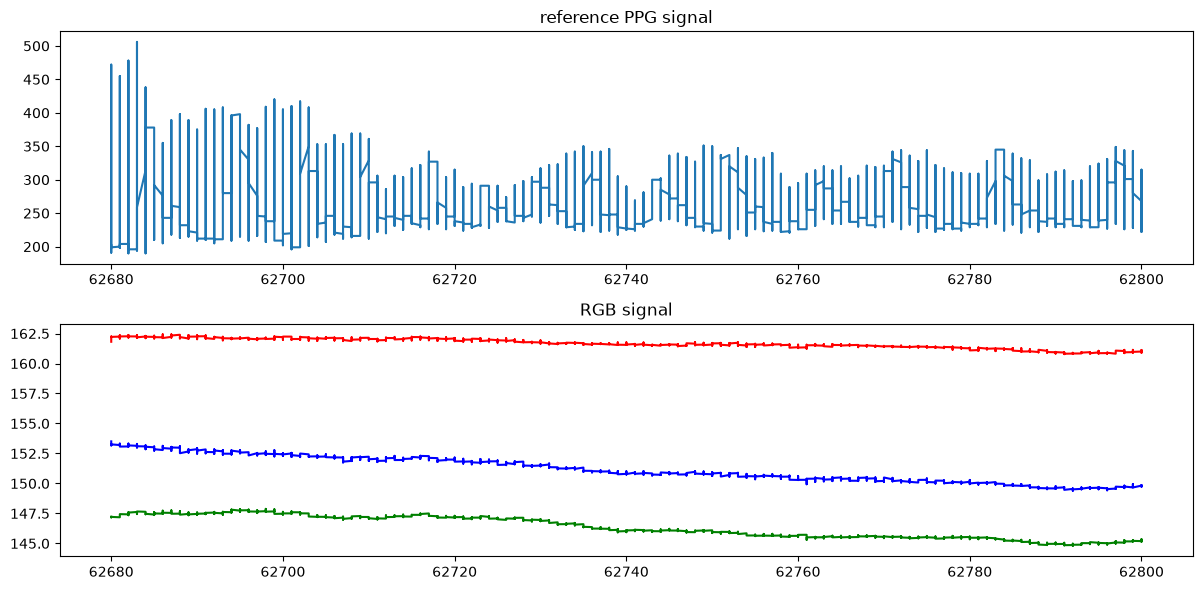

In [17]:
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1); plt.plot(TIMESTAMP_PPG, PPG); plt.title("reference PPG signal")
plt.subplot(2, 1, 2)
plt.plot(TIMESTAMP_RGB, R, 'r')
plt.plot(TIMESTAMP_RGB, G, 'g')
plt.plot(TIMESTAMP_RGB, B, 'b')
plt.title("RGB signal")

plt.tight_layout()

In [20]:
print(len(PPG))
print(len(R), len(G), len(B))

12084
3000 3000 3000


check Sampling rate stability, because real world hardware rarely operates perfectly

In [21]:
def count_per_second(timestamp):
    sec, n = np.unique(np.asarray(timestamp), return_counts = True)
    return sec, n

In [23]:
SEC_RGB, N_RGB = count_per_second(TIMESTAMP_RGB) #;print(SEC_RGB, N_RGB)
SEC_PPG, N_PPG = count_per_second(TIMESTAMP_PPG) #;print(SEC_PPG, N_PPG)

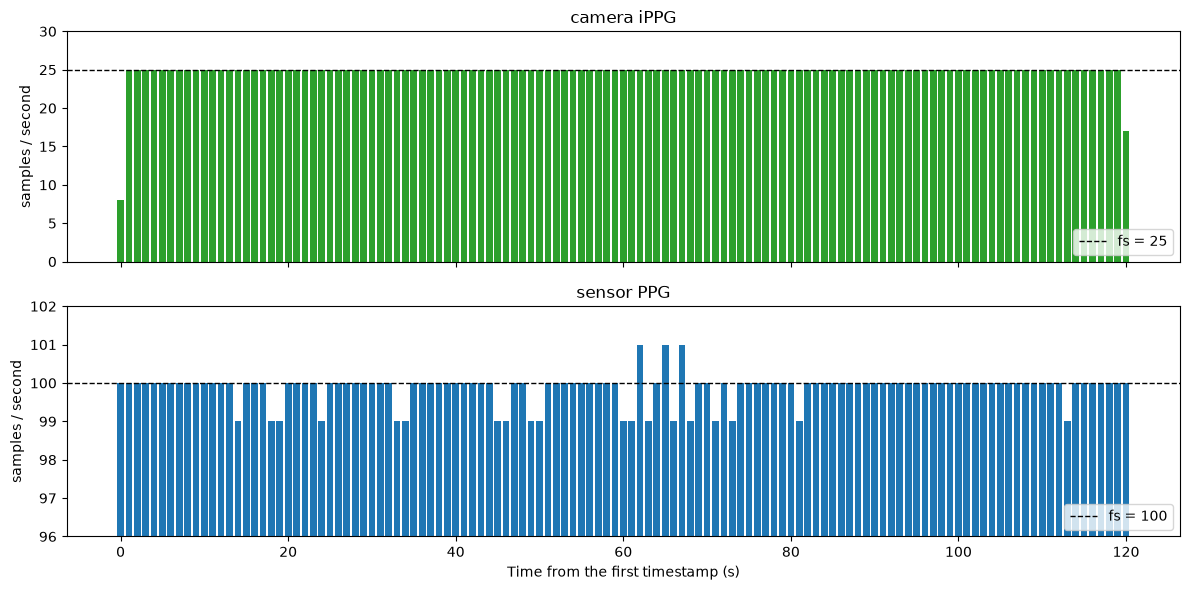

In [40]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for a, sec, n, fs, name, col in ((ax[0], SEC_RGB, N_RGB, FS_RGB, "camera iPPG", "tab:green"),
                                 (ax[1], SEC_PPG, N_PPG, FS_REF, "sensor PPG", "tab:blue")):
    a.bar(sec-sec[0], n, width = 0.8, color = col)
    a.axhline(fs, color = "k", ls="--", lw=1, label="fs = %g"%fs)
    a.set_ylabel("samples / second")
    a.set_title(name)
    a.legend(loc="lower right")

ax[0].set_ylim(0, 30)
ax[1].set_ylim(96, 102)
ax[1].set_xlabel("Time from the first timestamp (s)")
plt.tight_layout()